<a href="https://colab.research.google.com/github/iurikistenmacker/Laborat-rio/blob/main/IV_All.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Esse arquivo possui dados IV com a tensão variando de -2 a 2 V.
Insira a tensão mínima:-1
Insira a tensão máxima:1
A resistência nesse intervalo é: 2.18 MOhns


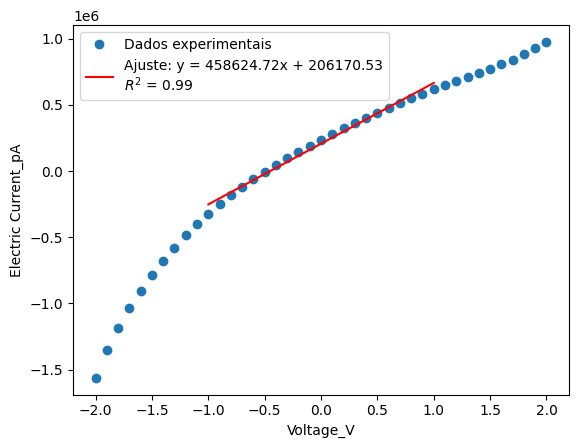

In [ ]:
from pathlib import Path
from posixpath import sep
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from itertools import zip_longest

def load_data(path):
    df = pd.read_csv(path, sep='\t')
    voltage = df['E /V'].values # FEZ UMA LISTA COM VALORES NUMÉRICOS DA COLUNA DO ARQUIVO QUE TA ESCRITO E /V
    Col_I = [c for c in df.columns if c.startswith('I /pA')] # FEZ UMA LISTA NUMÉRICA DAS COLUNAS QUE COMEÇAM COM I /pA
    current = df[Col_I].mean(axis=1).values # FEZ A MÉDIA DAS COLUNAS DE CORRENTE (AXIS=1 É MEDIA LINHA POR LINHA, AXIS=0 É MÉDIA DAS COLUNAS)
    return voltage, current

def ohmic(v_cortado, i_cortado):
    coeficientes = np.polyfit(v_cortado, i_cortado, 1) # FAZ MÉTODO DOS MÍNIMOS QUADRADOS PARA AJUSTAR POLINÔMIO DE GRAU 1, coeficientes ENTÃO É UMA LISTA DE DOIS ELEMENTOS NUMÉRICOS COM m e b DA RET
    modelo = np.poly1d(coeficientes) # PARA NÃO PRECISAR FAZER A CONTA NA MÃO TODA VEZ QUE USAR A FUNÇÃO
    x_ajuste = np.linspace(v_cortado.min(), v_cortado.max(), 100) # GERA SEQUENCIA DE 100 PONTOS COMEÇANDO NO MENOR VALOR DE TENSÃO ATÉ O MAIOR
    y_ajuste = modelo(x_ajuste)

    residuos = i_cortado - modelo(v_cortado)
    soma_residuos = np.sum(residuos**2)
    soma_media = np.sum((i_cortado - np.mean(i_cortado))**2)
    r2 = 1 - soma_residuos / soma_media
    return x_ajuste, y_ajuste, coeficientes, r2


path = '/content/m1-040526_GO_IV_59% RH.txt'

v, i = load_data(path)

print('Esse arquivo possui dados IV com a tensão variando de -2 a 2 V.')
v_min = float(input('Insira a tensão mínima:'))
v_max = float(input('Insira a tensão máxima:'))

mascara = (v >= v_min) & (v <= v_max)
v_cortado = v[mascara]
i_cortado = i[mascara]

x, y, coeficientes, r2 = ohmic(v_cortado, i_cortado)

resistencia_MOhns = ((1/coeficientes[0])*10**12)*10**-6
print(f'A resistência nesse intervalo é: {resistencia_MOhns:.2f} MOhns')

plt.plot(v, i, 'o', label='Dados experimentais')
plt.plot(x, y, color='red', label=f'Ajuste: y = {coeficientes[0]:.2f}x + {coeficientes[1]:.2f}\n$R^2$ = {r2:.2F}')
plt.xlabel('Voltage_V')
plt.ylabel('Electric Current_pA')
plt.legend(loc='upper left')

